# Shortest Path Problem (CLEMO)

This notebook reproduces the **Shortest Path Problem (SPP)** experiment from
*"Coherent Local Explanations for Mathematical Optimization"* (Section 4.1).

It is the simplest of the three experiments: a single sensitive parameter
`theta` perturbs all edge costs of a small graph as in *Parametric Optimization*, and we explain how
Dijkstra's algorithm reacts (objective value + 12 binary decision variables)
using:

- **LR**: independent linear / logistic regression per output component (the
  LIME-style benchmark, Eq. 5).
- **CLEMO**: the coherence-regularized surrogate (Eq. 10), fit with SLSQP.

Reproduces:

- **Figure 1** -- instance plot, CLEMO prediction of the objective value and
  of decision variable `x(s,a)`.
- **Table 1** -- fidelity and incoherence of LR vs. CLEMO.
- **Figure D.4** -- CLEMO predictions for *all* 12 decision variables.
- **Table C.7** (appendix) -- effect of different warm starts / initial
  points on the SLSQP solution.

Runtime: a few seconds on a laptop (1000 samples, 13-dimensional beta).


## 1. Setup

In [1]:
import copy
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.optimize import check_grad, minimize
from sklearn.linear_model import LinearRegression, LogisticRegression


## 2. Problem instance

We define the present SPP instance `G = (V, E, c)` together with a
perturbation direction `c_tilde`. Edge costs become `c + theta * c_tilde`,
so `theta = 0` corresponds to the present problem shown in **Figure 1(a)**
of the paper.


In [2]:
# Nodes and edges of the present SPP instance (Figure 1a)
node_list = ['s', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 't']
edge_list = [("s", "a"), ("s", "c"), ("a", "b"), ("a", "d"),
              ("c", "d"), ("c", "f"), ("b", "e"), ("d", "e"),
              ("d", "g"), ("f", "g"), ("g", "t"), ("e", "t")]

# Nominal edge costs c
SP_wgths_dct = {("s", "a"): {"cost": 6.5}, ("s", "c"): {"cost": 7.8},
                ("a", "b"): {"cost": 7.5}, ("a", "d"): {"cost": 2.5},
                ("c", "d"): {"cost": 1.5}, ("c", "f"): {"cost": 2.3},
                ("b", "e"): {"cost": 1.5}, ("d", "e"): {"cost": 6.3},
                ("d", "g"): {"cost": 4.1}, ("f", "g"): {"cost": 4.5},
                ("g", "t"): {"cost": 8.2}, ("e", "t"): {"cost": 6.5}}

# Perturbation direction c_tilde: edge costs become c + theta * c_tilde
SP_prtb_dct = {("s", "a"): {"cost": 0.5}, ("s", "c"): {"cost": 1.75},
               ("a", "b"): {"cost": 0.5}, ("a", "d"): {"cost": 0.5},
               ("c", "d"): {"cost": 0.7}, ("c", "f"): {"cost": 0.25},
               ("b", "e"): {"cost": 0.5}, ("d", "e"): {"cost": 1.25},
               ("d", "g"): {"cost": 1.1}, ("f", "g"): {"cost": 0.5},
               ("g", "t"): {"cost": 1.15}, ("e", "t"): {"cost": 0.5}}

G = nx.Graph()
G.add_nodes_from(node_list)
G.add_edges_from(edge_list)
nx.set_edge_attributes(G, SP_wgths_dct)

org_csts = np.array([SP_wgths_dct[e]['cost'] for e in edge_list])
prt_csts = np.array([SP_prtb_dct[e]['cost'] for e in edge_list])


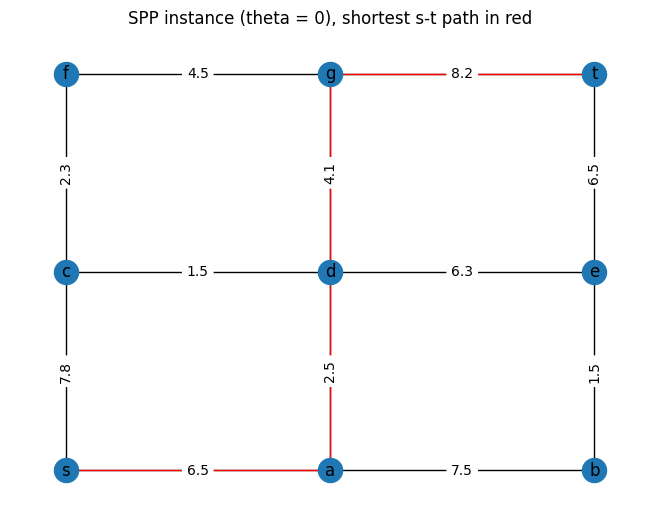

In [3]:
# Plot the instance with the present (theta=0) shortest s-t path highlighted
pos = {"s": (0, 0), "a": (1, 0), "b": (2, 0),
       "c": (0, 1), "d": (1, 1), "e": (2, 1),
       "f": (0, 2), "g": (1, 2), "t": (2, 2)}

sp = nx.shortest_path(G, "s", "t", weight='cost')
e_sp = list(zip(sp, sp[1:]))
edge_labels = nx.get_edge_attributes(G, "cost")

nx.draw(G, pos, with_labels=True)
nx.draw_networkx_edges(G, pos, edgelist=e_sp, edge_color="r")
nx.draw_networkx_edge_labels(G, pos, edge_labels)
plt.title("SPP instance (theta = 0), shortest s-t path in red")
plt.show()


### 2.1 Global settings

In [4]:
# Global experiment settings
nr_edges = len(edge_list)
smple_sz = 1000          # number of sampled parameter values (Algorithm 1, N)
epsilon = 1e-4

# Implied dimensions
nr_trgts = nr_edges + 1          # objective value + 12 binary decision variables
nr_ftres = 1                      # single sensitive parameter theta
nr_ftres_intrcpt = nr_ftres + 1   # + intercept

np.random.seed(42)

In [6]:
# Sanity check: solve the present problem (theta = 0) and print its solution
print('Shortest path cost:', np.round(nx.shortest_path_length(G, "s", "t", weight='cost'), 4))
print('Shortest path     :', sp)

for edge in edge_list:
    in_path = edge[0] in sp and edge[1] in sp
    print(f'  Decision variable{edge} value: {int(in_path)}')


Shortest path cost: 21.3
Shortest path     : ['s', 'a', 'd', 'g', 't']
  Decision variable('s', 'a') value: 1
  Decision variable('s', 'c') value: 0
  Decision variable('a', 'b') value: 0
  Decision variable('a', 'd') value: 1
  Decision variable('c', 'd') value: 0
  Decision variable('c', 'f') value: 0
  Decision variable('b', 'e') value: 0
  Decision variable('d', 'e') value: 0
  Decision variable('d', 'g') value: 1
  Decision variable('f', 'g') value: 0
  Decision variable('g', 't') value: 1
  Decision variable('e', 't') value: 0


## 3. Solver

`shortest_path_solver` is the solution algorithm `h` from Eq. (2): given a
vector of edge costs, it returns the optimal objective value and the
incidence vector `x` of the shortest path (Dijkstra's algorithm via
`networkx`).


In [7]:
def shortest_path_solver(vals, output='all', G_org=G, start='s', end='t'):
    """Solve the parametrized SPP for the given edge costs `vals`.

    Args:
        vals: edge costs, in the order of `edge_list`.
        output: one of {'all', 'objective', 'path', 'bounded', 'feasibility'}.
        G_org: graph template (edge costs are overwritten with `vals`).
        start, end: source and terminal node.

    Returns:
        Depending on `output`:
          - 'all': [objective_value, x_1, ..., x_{|E|}]  (Eq. 2 target h(theta))
          - 'objective': scalar shortest-path length
          - 'path': list of nodes on the shortest path
          - 'bounded'/'feasibility': always True for SPP with positive costs
    """
    G_loc = copy.deepcopy(G_org)
    weights_local = {edge_list[i]: {'cost': vals[i]} for i in range(len(edge_list))}
    nx.set_edge_attributes(G_loc, weights_local)

    if output == 'all':
        path = nx.shortest_path(G_loc, start, end, weight='cost')
        target = [nx.shortest_path_length(G_loc, start, end, weight='cost')]
        for edge in edge_list:
            target.append(1 if (edge[0] in path and edge[1] in path) else 0)
        return target

    elif output in ('bounded', 'feasibility'):
        return vals.all() > 0

    elif output == 'path':
        return nx.shortest_path(G_loc, start, end, weight='cost')

    elif output == 'objective':
        return nx.shortest_path_length(G_loc, start, end, weight='cost')

    raise ValueError(f"Unsupported output type: {output!r}")


## 4. Feasible region: flow constraints

The feasible region `X(theta)` of the SPP is given by flow-conservation
constraints at every node (Eq. A.1, Appendix A). `flow_constraints` evaluates
these for a batch of (possibly fractional, predicted) decision vectors `x`;
`jac_flow_constraints` provides the corresponding Jacobian used by the
CLEMO subgradient (Eq. 8-9).


In [8]:
def flow_constraints(x):
    """Flow-conservation residuals (Eq. A.1) for a batch of decision vectors.

    Each row of `x` is a (possibly fractional) prediction of the 12 edge
    indicator variables, ordered as in `edge_list`. Returns one column per
    node-flow constraint; a value of 0 means the constraint is satisfied.
    """
    ones = np.ones(np.shape(x[:, 0]))
    constraints = [
        x[:, 0] + x[:, 1] - ones,                 # flow out of s
        x[:, 0] - x[:, 2] - x[:, 3],              # node a
        x[:, 1] - x[:, 4] - x[:, 5],              # node c
        x[:, 2] - x[:, 6],                        # node b
        x[:, 3] + x[:, 4] - x[:, 7] - x[:, 8],    # node d
        x[:, 6] + x[:, 7] - x[:, 11],             # node e
        x[:, 5] - x[:, 9],                        # node f
        x[:, 8] + x[:, 9] - x[:, 10],             # node g
        x[:, 10] + x[:, 11] - ones,               # flow into t
    ]
    return np.transpose(np.array(constraints))


# Sparse incidence matrix mapping the 9 flow constraints to the 12 edge variables,
# used to apply the chain rule when differentiating `flow_constraints`.
_FLOW_INCIDENCE = np.array([
    [1, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, -1, 0, 1, 0, 0, 0, 0, 0],
    [0, -1, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, -1, 0, 1, 0, 0, 0, 0],
    [0, 0, -1, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, -1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, -1, 1, 0, 0, 0],
    [0, 0, 0, 0, -1, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, -1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, -1, 1],
    [0, 0, 0, 0, 0, -1, 0, 0, 1],
]).T


def jac_flow_constraints(x):
    """Jacobian of `flow_constraints` w.r.t. the 12 decision variables."""
    return np.matmul(flow_constraints(x), _FLOW_INCIDENCE)


## 5. Sampling: building the training dataset

Following Algorithm 1/2, we sample `theta_i ~ U[-1, 1]` (1000 samples,
including the present problem `theta = 0`), solve the SPP for each sample,
and compute RBF sample weights based on Euclidean distance to `theta = 0`
(Eq. 11).


In [9]:
def get_values_from_samples(samples, model, hyperparams=None):
    """Apply `model` to each sample and collect the outputs h(theta_i)."""
    hyperparams = hyperparams or {}
    return [model(s, **hyperparams) for s in samples]


def std_weight_function(a, b, kernel_width=None):
    """RBF kernel weight w_i = exp(-d(a,b)^2 / nu^2), Eq. (11)."""
    d = np.linalg.norm(a - b)
    nu = 0.75 if kernel_width is None else kernel_width
    return np.exp(-(d ** 2) / (2 * nu ** 2))


def get_weights_from_samples(samples, function=None, width=None):
    """RBF weights of all samples relative to the first sample (theta_0)."""
    origin = samples[0]
    if function is not None:
        return [function(origin, s) for s in samples]
    return [std_weight_function(origin, s, width) for s in samples]

In [10]:
# Sample theta uniformly on [-1, 1], always including theta = 0 (the present problem)
lmb_smpls = np.sort(np.concatenate(([0], np.random.uniform(-1, 1, smple_sz - 1))))
samples = [[theta, 1.0] for theta in lmb_smpls]  # design matrix X (with intercept column)

# Perturbed edge-cost vectors c + theta * c_tilde
cst_smpls = [org_csts + theta * prt_csts for theta in lmb_smpls]

#Euclidean distances to theta0=0
d_list = [np.linalg.norm(lmb_smpls[0] - theta) for theta in lmb_smpls]

# Targets h(theta_i) = [objective value, x_1, ..., x_12] and RBF weights
actuals = get_values_from_samples(cst_smpls, shortest_path_solver, hyperparams={'output': 'all'})
weights = get_weights_from_samples(lmb_smpls, width=np.mean(d_list))

# Cost matrix C (Eq. 8): row i holds the edge costs of sample i
Cost_matrix = np.array(cst_smpls)

# Explain all 12 decision variables
all_trgs = list(range(nr_edges))

## 6. Loss functions

`lss_all` implements the CLEMO objective (Eq. 10) for this problem:

- a weighted squared-error term for the objective-value prediction,
- a weighted log-loss term for the (binary, sigmoid-transformed) decision
  variables,
- the **objective-coherence** regularizer (Eq. 8, first term, condition 3),
- the **feasibility** regularizer (Eq. 8/9, second term, condition 4, using
  `flow_constraints`).

`lss_all_jac_sg` is the corresponding (sub)gradient, used by SLSQP.
`lss_std`, `lss_log`, `lss_obj`, `lss_cns` expose the four loss components
individually -- these are what Table 1 reports.


In [11]:
def sig(x):
    """Numerically stable sigmoid, clipped outside [-30, 30]."""
    x = np.asarray(x)
    out = np.empty_like(x, dtype=float)
    out[x > 30] = 1.0
    out[x < -30] = 0.0
    mask = (x >= -30) & (x <= 30)
    out[mask] = 1 / (1 + np.exp(-x[mask]))
    return out


def lg1(x):
    """log(sigmoid(x)), clipped outside [-30, 30]."""
    x = np.asarray(x)
    out = np.empty_like(x, dtype=float)
    out[x > 30] = 0.0
    out[x < -30] = np.log(1 / (1 + np.exp(30)))
    mask = (x >= -30) & (x <= 30)
    out[mask] = np.log(1 / (1 + np.exp(-x[mask])))
    return out


def lg2(x):
    """log(1 - sigmoid(x)), clipped outside [-30, 30]."""
    x = np.asarray(x)
    out = np.empty_like(x, dtype=float)
    out[x < -30] = 0.0
    out[x > 30] = np.log(1 - 1 / (1 + np.exp(-30)))
    mask = (x >= -30) & (x <= 30)
    out[mask] = np.log(1 - 1 / (1 + np.exp(-x[mask])))
    return out

In [15]:
def _split_predictions(beta, X, Y, keep_columns):
    """Shared bookkeeping for the loss functions below.

    Returns the objective-value predictions, the (sigmoid) decision-vector
    predictions with non-explained columns replaced by their true values, and
    the matching slice of the true decision vectors.
    """
    Y_dcv = Y[:, 1:]
    obj_prd = np.matmul(X, beta)[:, 0]
    dcv_prd = sig(np.matmul(X, beta)[:, 1:])

    all_columns = set(range(nr_trgts - 1))
    replace_columns = list(all_columns - set(keep_columns))
    dcv_prd_keep = dcv_prd.copy()
    dcv_prd_keep[:, replace_columns] = Y_dcv[:, replace_columns]

    return obj_prd, dcv_prd, dcv_prd_keep, Y_dcv


def lss_all(beta, X=samples, Y=actuals, W=weights, lgr_std=1, lgr_log=1, lgr_obj=1,
            lgr_cns=1, oneD=True, C=Cost_matrix, keep_columns=all_trgs):
    """Total CLEMO loss (Eq. 10): fidelity + objective + feasibility terms.

    Args:
        beta: surrogate coefficients, flattened if `oneD` is True
              (shape (nr_ftres_intrcpt, nr_trgts)).
        X, Y, W: design matrix, targets h(theta_i), and RBF sample weights.
        lgr_std, lgr_log, lgr_obj, lgr_cns: loss weights lambda_{F1..C2}.
        C: cost matrix used to evaluate f(g_x(theta); theta).
        keep_columns: indices of decision variables to explain.

    Returns:
        Scalar total weighted loss.
    """
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)

    W, X, Y = np.array(W), np.array(X), np.array(Y)
    obj_prd, dcv_prd, dcv_prd_keep, Y_dcv = _split_predictions(beta, X, Y, keep_columns)
    Y_dcv_kp = Y_dcv[:, keep_columns]

    dcv_lg1 = lg1(np.matmul(X, beta)[:, 1:])[:, keep_columns]
    dcv_lg2 = lg2(np.matmul(X, beta)[:, 1:])[:, keep_columns]

    std_err = np.sum(W * np.square(Y[:, 0] - obj_prd))
    log_err = -np.sum(W * (np.sum(Y_dcv_kp * dcv_lg1 + (1 - Y_dcv_kp) * dcv_lg2, axis=1)))
    obj_err = np.sum(W * np.square(obj_prd - np.sum(dcv_prd_keep * C, axis=1)))
    cns_err = np.sum(W * np.sum(np.square(flow_constraints(dcv_prd_keep)), axis=1))

    return lgr_std * std_err + lgr_cns * cns_err + lgr_log * log_err + lgr_obj * obj_err


def lss_all_jac_sg(beta, X=samples, Y=actuals, W=weights, lgr_std=1, lgr_log=1, lgr_obj=1,
                   lgr_cns=1, oneD=True, C=Cost_matrix, keep_columns=all_trgs):
    """(Sub)gradient of `lss_all` w.r.t. `beta`, used as the SLSQP Jacobian."""
    grad = np.zeros((nr_ftres_intrcpt, nr_trgts))
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)

    W, X, Y = np.array(W), np.array(X), np.array(Y)
    Y_dcv = Y[:, 1:]

    obj_prd = np.matmul(X, beta)[:, 0]
    dcv_prd = sig(np.matmul(X, beta)[:, 1:])

    all_columns = set(range(nr_trgts - 1))
    replace_columns = list(all_columns - set(keep_columns))
    dcv_prd_keep = dcv_prd.copy()
    dcv_prd_keep[:, replace_columns] = Y_dcv[:, replace_columns]

    tmp_std = Y[:, 0] - obj_prd
    tmp_obj = obj_prd - np.sum(dcv_prd_keep * C, axis=1)
    tmp_cns = jac_flow_constraints(dcv_prd_keep)

    for k in range(grad.shape[0]):
        for j in range(grad.shape[1]):
            if j == 0:  # objective value column
                grad[k, j] -= 2 * lgr_std * np.sum(W * X[:, k] * tmp_std)
                grad[k, j] += 2 * lgr_obj * np.sum(W * X[:, k] * tmp_obj)
            elif (j - 1) in keep_columns:  # decision-variable columns
                d = dcv_prd[:, j - 1]
                grad[k, j] -= lgr_log * (abs(beta[k, j]) < 30) * np.sum(
                    W * X[:, k] * (Y[:, j] - d))
                grad[k, j] -= 2 * lgr_obj * np.sum(
                    W * d * (1 - d) * X[:, k] * C[:, j - 1] * tmp_obj)
                grad[k, j] += 2 * lgr_cns * np.sum(
                    W * d * (1 - d) * X[:, k] * tmp_cns[:, j - 1])

    return grad.flatten()


def lss_std(beta, X=samples, Y=actuals, W=weights, oneD=True):
    """Fidelity loss of the objective-value prediction (weighted squared error)."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)
    W, X, Y = np.array(W), np.array(X), np.array(Y)
    return np.sum(W * np.square(Y[:, 0] - np.matmul(X, beta)[:, 0]))


def lss_log(beta, X=samples, Y=actuals, W=weights, oneD=True, keep_columns=all_trgs):
    """Fidelity loss of the decision-vector predictions (weighted log loss)."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)
    W, X, Y = np.array(W), np.array(X), np.array(Y)
    Y_dcv_kp = Y[:, 1:][:, keep_columns]
    dcv_lg1 = lg1(np.matmul(X, beta)[:, 1:])[:, keep_columns]
    dcv_lg2 = lg2(np.matmul(X, beta)[:, 1:])[:, keep_columns]
    return -np.sum(W * np.sum(Y_dcv_kp * dcv_lg1 + (1 - Y_dcv_kp) * dcv_lg2, axis=1))


def lss_obj(beta, X=samples, Y=actuals, W=weights, oneD=True, C=Cost_matrix, keep_columns=all_trgs):
    """Objective-coherence loss: violation of condition (3), R_C1."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)
    W, X, Y = np.array(W), np.array(X), np.array(Y)
    _, _, dcv_prd_keep, _ = _split_predictions(beta, X, Y, keep_columns)
    obj_prd = np.matmul(X, beta)[:, 0]
    return np.sum(W * np.square(obj_prd - np.sum(dcv_prd_keep * C, axis=1)))


def lss_cns(beta, X=samples, Y=actuals, W=weights, oneD=True, keep_columns=all_trgs):
    """Feasibility loss: violation of condition (4), R_C2."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)
    W, X, Y = np.array(W), np.array(X), np.array(Y)
    _, _, dcv_prd_keep, _ = _split_predictions(beta, X, Y, keep_columns)
    return np.sum(W * np.sum(np.square(flow_constraints(dcv_prd_keep)), axis=1))


## 7. Results

### 7.1. Warm start (LR benchmark)

Before solving the CLEMO problem (10), we fit independent linear/logistic
regression models per output component -- this is exactly the LIME-style
benchmark `LR` from Eq. (5), and also serves as the warm start for SLSQP.


In [13]:
def get_warm_start_reg(X, Y, W):
    """Fit independent linear/logistic regressions per output component.

    This is the LR benchmark of Eq. (5): a LinearRegression for the
    objective value, and a LogisticRegression for each binary decision
    variable (or a fixed extreme coefficient if a variable is constant
    across all samples).

    Args:
        X: theta samples, shape (N,).
        Y: targets h(theta_i), shape (N, nr_trgts).
        W: RBF sample weights, shape (N,).

    Returns:
        beta, shape (nr_ftres_intrcpt, nr_trgts).
    """
    models = []
    for j in range(len(Y[0])):
        y_col = [row[j] for row in Y]
        if j == 0:
            clf = LinearRegression()
            clf.fit(X.reshape(-1, 1), y_col, sample_weight=W)

        # Decision variables: binary, use LinearRegression if
        # samples contain both 0 and 1 values, fix parameters otherwise
        elif sum(y_col) == len(y_col):
            clf = 'All 1'
        elif sum(y_col) == 0:
            clf = 'All 0'
        else:
            clf = LogisticRegression()
            clf.fit(X.reshape(-1, 1), [int(v) for v in y_col], sample_weight=W)
        models.append(clf)

    beta_T = np.zeros((len(Y[0]), nr_ftres_intrcpt))
    for i, model in enumerate(models):
        if model == 'All 1':
            beta_T[i, -1] = 30   # sigmoid(30) ~= 1
        elif model == 'All 0':
            beta_T[i, -1] = -30  # sigmoid(-30) ~= 0
        elif any(isinstance(c, np.ndarray) for c in model.coef_):
            beta_T[i, 0] = model.coef_[0][0]
            beta_T[i, -1] = model.intercept_[0]
        else:
            beta_T[i, 0] = model.coef_[0]
            beta_T[i, -1] = model.intercept_
    return beta_T.T


start_time = time.time()
wrm_strt_lcl = get_warm_start_reg(np.array(lmb_smpls), actuals, weights)
print(f'LR warm start computed in {time.time() - start_time:.4f} s')


LR warm start computed in 0.0194 s


In [16]:
# Individual loss components at the LR warm start (used as Lmax reference, Sec. 4)
lcl_lss_all = lss_all(wrm_strt_lcl, X=samples, Y=actuals, W=weights)
lcl_lss_std = lss_std(wrm_strt_lcl, X=samples, Y=actuals, W=weights)
lcl_lss_log = lss_log(wrm_strt_lcl, X=samples, Y=actuals, W=weights)
lcl_lss_obj = lss_obj(wrm_strt_lcl, X=samples, Y=actuals, W=weights)
lcl_lss_cns = lss_cns(wrm_strt_lcl, X=samples, Y=actuals, W=weights)

print(f'LR  fidelity (objective)      : {lcl_lss_std:.4f}')
print(f'LR  fidelity (decision vector): {lcl_lss_log:.4f}')
print(f'LR  incoherence (objective)   : {lcl_lss_obj:.4f}')
print(f'LR  incoherence (feasibility) : {lcl_lss_cns:.4f}')


LR  fidelity (objective)      : 32.0307
LR  fidelity (decision vector): 648.0613
LR  incoherence (objective)   : 112.5150
LR  incoherence (feasibility) : 54.5549


In [17]:
# Sanity check: the analytical subgradient matches a finite-difference gradient
grad_error = check_grad(lss_all, lss_all_jac_sg, wrm_strt_lcl.flatten())
print(f'Gradient check error: {grad_error:.2e}')

Gradient check error: 7.54e-03


### 7.2 Fitting CLEMO (Eq. 10)

We balance the four loss terms following the rule described in Section 4
(`Setup`): each term `L_j` is weighted by `lambda_j = 1` if it is the
largest (or zero), and `lambda_j = 0.5 * L_max / L_j` otherwise. CLEMO is
then fit by minimizing `lss_all` with SLSQP, warm-started at the LR
solution.


In [18]:
def lss_all_input(beta, lmb_1, lmb_2, lmb_3, lmb_4):
    return lss_all(beta=beta, lgr_std=lmb_1, lgr_log=lmb_2, lgr_obj=lmb_3, lgr_cns=lmb_4)


def lss_all_jac_input(beta, lmb_1, lmb_2, lmb_3, lmb_4):
    return lss_all_jac_sg(beta=beta, lgr_std=lmb_1, lgr_log=lmb_2, lgr_obj=lmb_3, lgr_cns=lmb_4)


# Balance the four loss components: lambda_j = 1 for the largest term,
# 0.5 * L_max / L_j for the others (skipped if L_j is (near) zero).
lss_list = [lcl_lss_std, lcl_lss_log, lcl_lss_obj, lcl_lss_cns]
max_lss_i = int(np.argmax(lss_list))

lmb_lst = np.ones(4)
for i in range(4):
    if i != max_lss_i and lss_list[i] > 0.01:
        lmb_lst[i] = 0.5 * lss_list[max_lss_i] / lss_list[i]

args_RLR = tuple(lmb_lst)
print('Loss weights (lambda_std, lambda_log, lambda_obj, lambda_cns):', args_RLR)


Loss weights (lambda_std, lambda_log, lambda_obj, lambda_cns): (np.float64(10.116241562497711), np.float64(1.0), np.float64(2.8798880217835654), np.float64(5.939538466425724))


In [19]:
# Fit CLEMO with SLSQP, warm-started at the LR solution
start_time = time.time()
sol_RLR_lcl = minimize(
    lss_all_input, wrm_strt_lcl.flatten(), args=args_RLR,
    method='SLSQP', jac=lss_all_jac_input, options={'maxiter': 1000},
)
clemo_fit_time = time.time() - start_time
print(f'CLEMO fit in {clemo_fit_time:.2f} s, final loss = {sol_RLR_lcl.fun:.4f}')


CLEMO fit in 0.24 s, final loss = 1151.9334


#### 7.2.1. Table 1: fidelity and incoherence (LR vs. CLEMO)

This reproduces Table 1: CLEMO achieves comparable fidelity while
substantially reducing both incoherence terms compared to LR.


In [20]:
beta_sol = sol_RLR_lcl.x.reshape(nr_ftres_intrcpt, nr_trgts)

print(f"{'Method':<8}{'Infid. (obj)':>14}{'Infid. (dec.vec.)':>20}{'Incoh. (obj)':>14}{'Incoh. (feas.)':>16}")
for name, beta in [('LR', wrm_strt_lcl), ('CLEMO', sol_RLR_lcl.x)]:
    print(f"{name:<8}{lss_std(beta):>14.2f}{lss_log(beta):>20.2f}{lss_obj(beta):>14.2f}{lss_cns(beta):>16.2f}")


Method    Infid. (obj)   Infid. (dec.vec.)  Incoh. (obj)  Incoh. (feas.)
LR               32.03              648.06        112.52           54.55
CLEMO            32.12              646.28          6.91           27.08


#### 7.2.2. Figure 1: predictions vs. actual values

Plot CLEMO's prediction of the objective value (Fig. 1b) and of the decision
variable `x(s,a)` (Fig. 1c) as functions of `theta`.


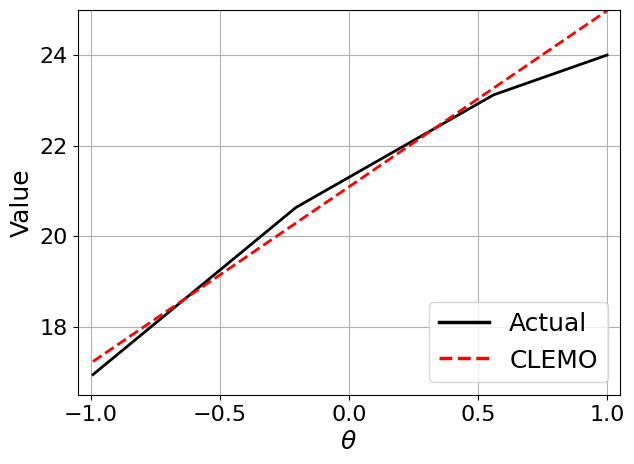

In [21]:
plt.rcParams.update({
    'font.size': 18, 'axes.labelsize': 18,
    'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 18,
})

legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', linewidth=2.5, label='Actual'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=2.5, label='CLEMO'),
]


def plot_prediction(actual, predicted, ylabel, ylim=None):
    fig = plt.figure(figsize=(7, 5))
    sns.lineplot(x=lmb_smpls, y=actual, color='black', linestyle='-', linewidth=2)
    sns.lineplot(x=lmb_smpls, y=predicted, color='red', linestyle='--', linewidth=2)
    plt.gca().grid(True)
    plt.legend(handles=legend_elements, loc='lower right')
    plt.xlabel(r'$\theta$')
    plt.ylabel(ylabel)
    plt.xlim(-1.05, 1.05)
    if ylim:
        plt.ylim(*ylim)
    plt.gca().set_xticks(np.arange(-1, 1.1, 0.5))
    plt.show()


# Figure 1(b): objective value
obj_prd = np.matmul(samples, beta_sol)[:, 0]
obj_act = np.array(actuals)[:, 0]
plot_prediction(obj_act, obj_prd, 'Value', ylim=(16.5, 25))


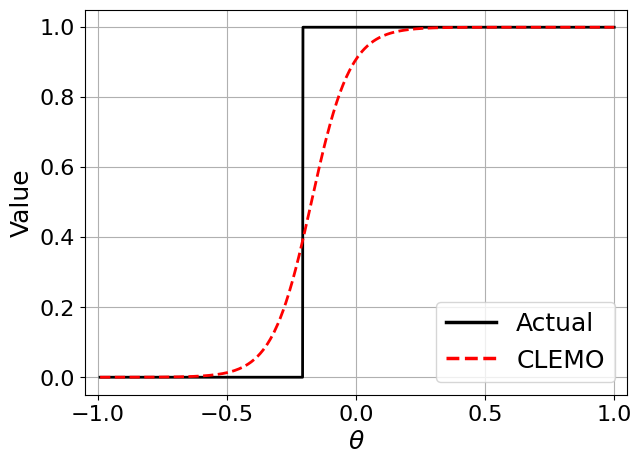

In [22]:
# Figure 1(c): decision variable x(s,a) (edge index 0)
edge_idx = 0
x0_act = np.array(actuals)[:, edge_idx + 1]
x0_prd = sig(np.matmul(samples, beta_sol)[:, edge_idx + 1])
plot_prediction(x0_act, x0_prd, 'Value')


#### 7.2.3. Figure D.4: predictions for all decision variables

Grid of CLEMO predictions vs. actual values for all 12 edges of the SPP
instance (Appendix D.1).


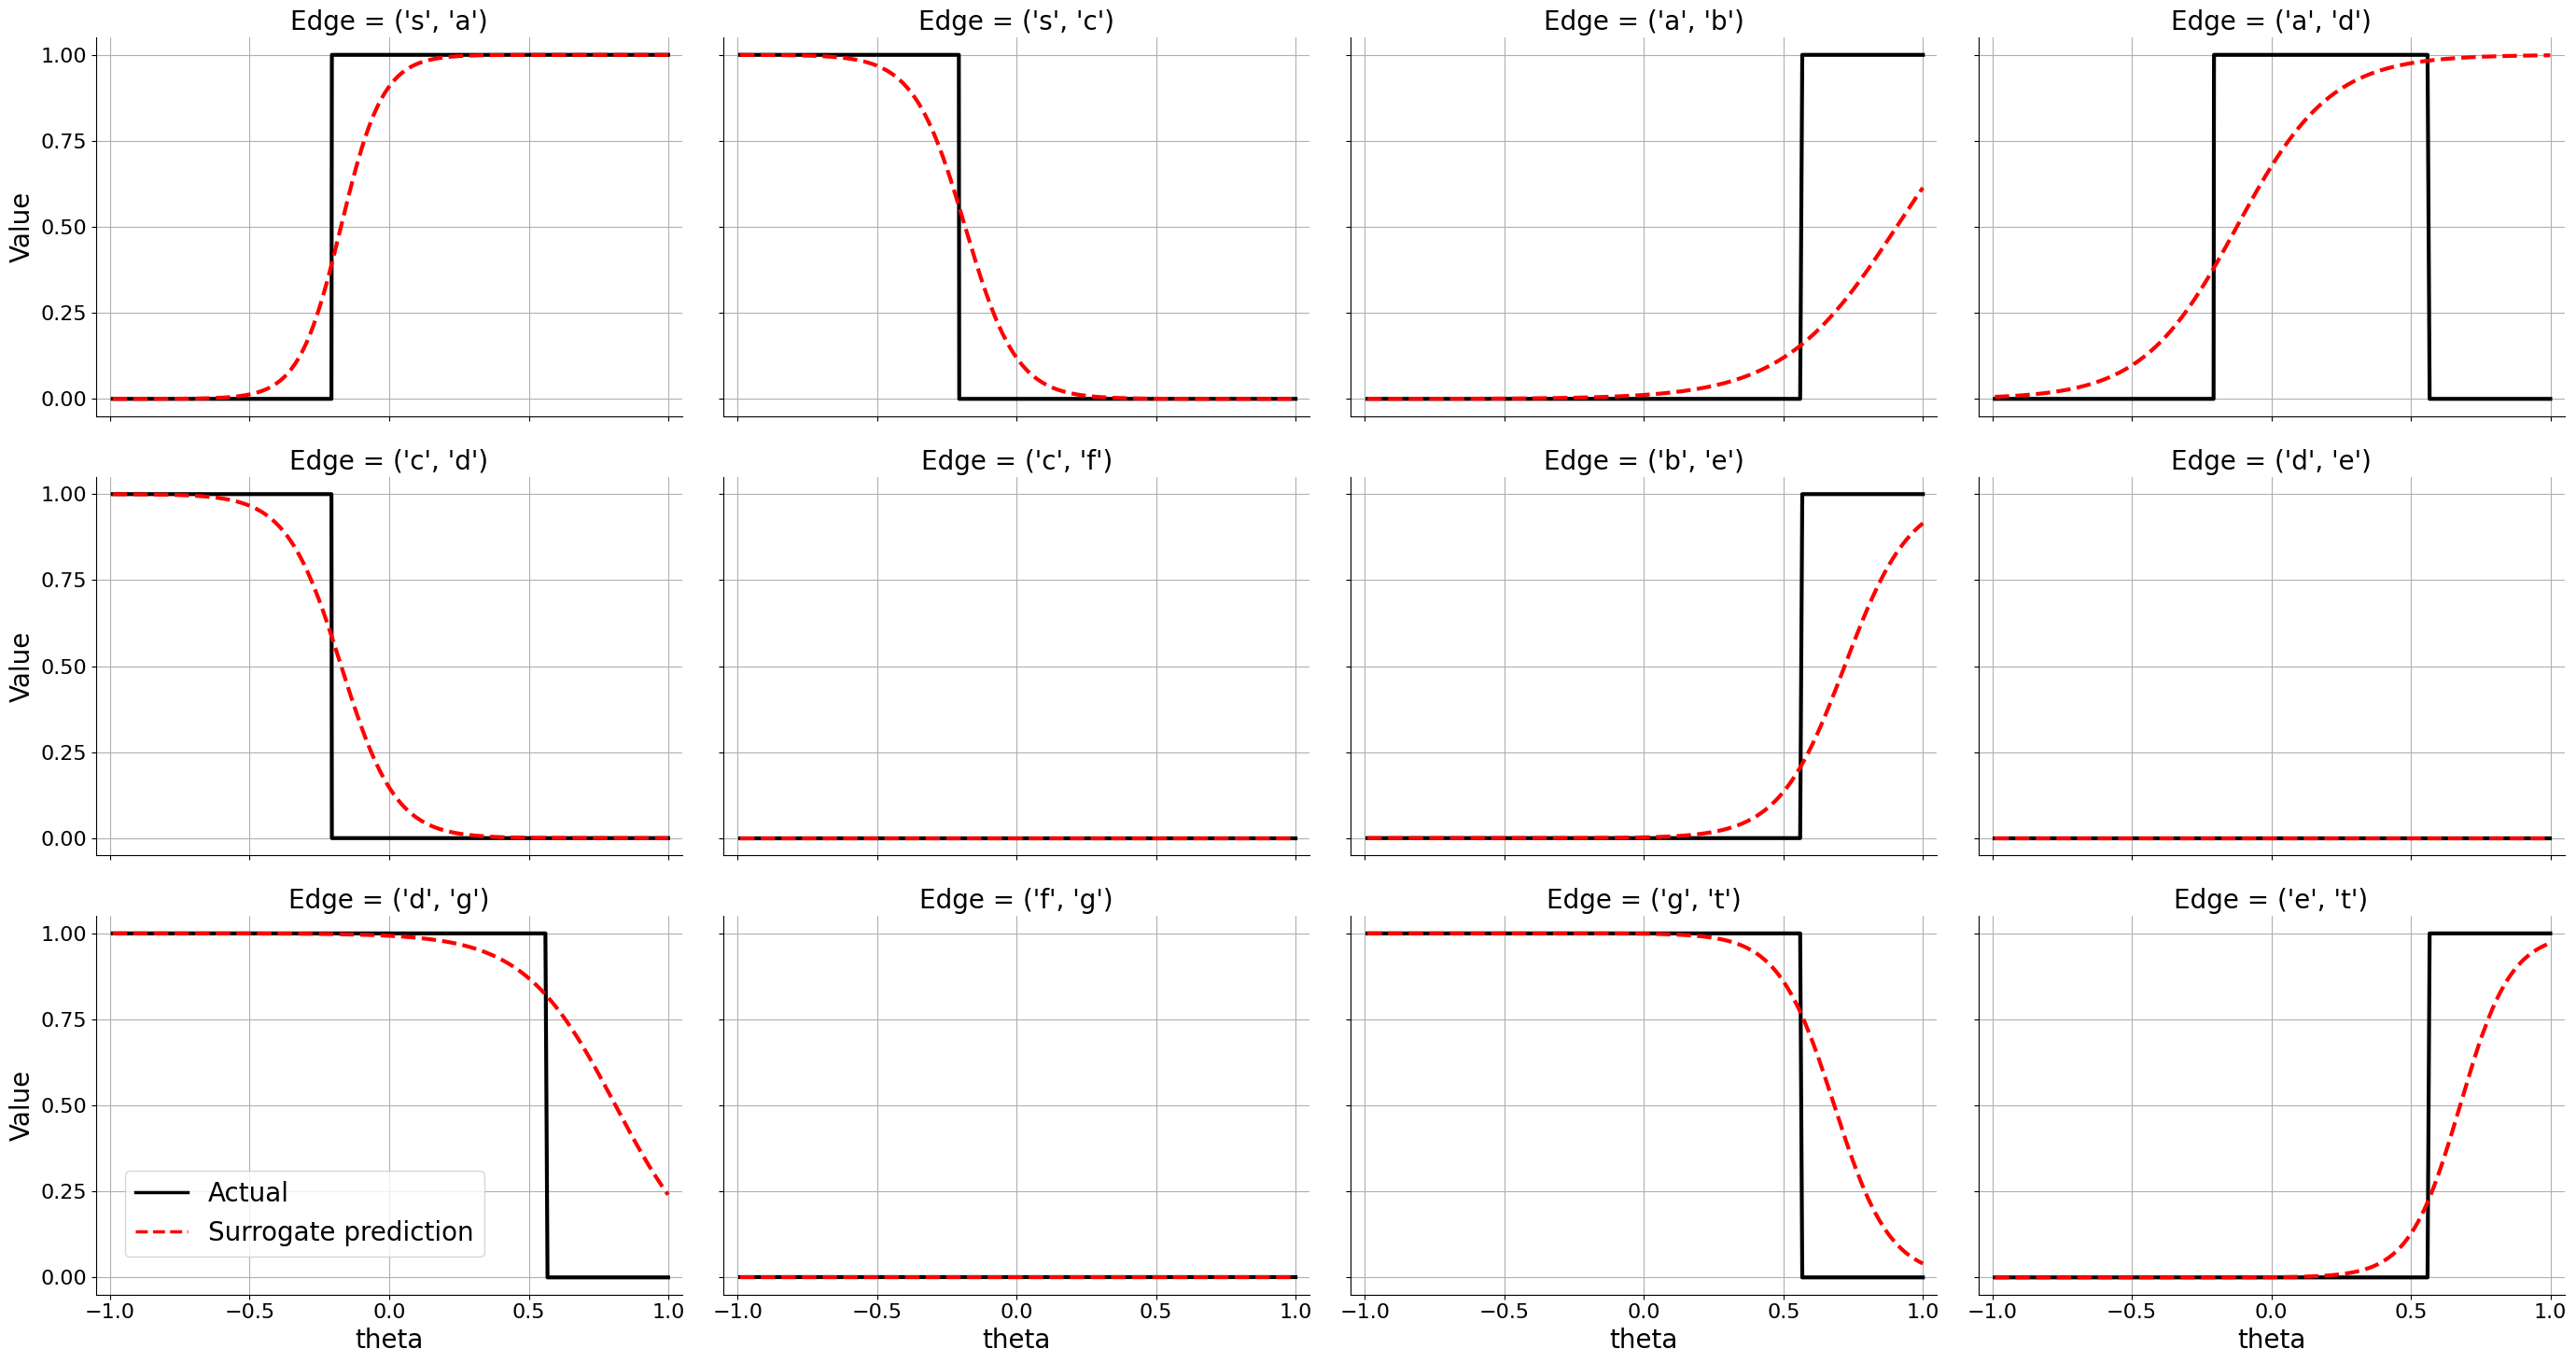

In [23]:
import pandas as pd

plt.rcParams.update({
    'font.size': 20, 'axes.labelsize': 20,
    'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 20,
})

records = []
for idx in all_trgs:
    edge_name = str(edge_list[idx])
    pred = sig(np.matmul(samples, beta_sol)[:, idx + 1])
    actual = np.array(actuals)[:, idx + 1]
    for theta, val in zip(lmb_smpls, actual):
        records.append({'theta': theta, 'Value': val, 'line': 'Actual', 'Edge': edge_name})
    for theta, val in zip(lmb_smpls, pred):
        records.append({'theta': theta, 'Value': val, 'line': 'Surrogate prediction', 'Edge': edge_name})

df_dcv = pd.DataFrame(records)

custom_palette = {'Surrogate prediction': 'red', 'Actual': 'black'}


def plot_lines(data, x, y, hue, **kwargs):
    for label, style, lw in [('Actual', '-', 3), ('Surrogate prediction', '--', 3)]:
        subset = data[data[hue] == label]
        sns.lineplot(data=subset, x=x, y=y, color=custom_palette[label], linestyle=style, linewidth=lw)


g = sns.FacetGrid(df_dcv, col='Edge', col_wrap=4, height=5, aspect=1.4, sharex=True, sharey=True)
g.map_dataframe(plot_lines, x='theta', y='Value', hue='line')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', linewidth=2.5, label='Actual'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=2.5, label='Surrogate prediction'),
]
g.fig.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(0.05, 0.08))

g.set(xlim=(-1.05, 1.05), ylim=(-0.05, 1.05))
g.set(xticks=np.arange(-1, 1.1, 0.5), yticks=np.arange(0, 1.1, 0.25))
for ax in g.axes:
    if ax.get_legend():
        ax.get_legend().remove()
    ax.grid(True)

plt.tight_layout()
plt.show()


#### 7.2.4. Table C.7 (appendix): different initializations

We additionally run CLEMO with L-BFGS-B from (i) an all-zeros start,
(ii) an all-ones start, and (iii) 10 random starts drawn from
`U[-10, 10]`, and compare against the SLSQP warm-started solution. Because
of the logistic-regression terms, this is a non-convex problem; the table
shows the method is nevertheless robust to the initialization, at the cost
of additional runtime.


In [24]:
def run_lbfgsb(x0, label):
    start_time = time.time()
    sol = minimize(lss_all_input, x0, args=args_RLR, method='L-BFGS-B',
                    jac=lss_all_jac_input, options={'maxiter': 100_000})
    elapsed = time.time() - start_time
    print(f'{label:<28} infid.(obj)={lss_std(sol.x):7.2f}  infid.(dec)={lss_log(sol.x):8.2f}  '
          f'incoh.(obj)={lss_obj(sol.x):6.2f}  incoh.(feas)={lss_cns(sol.x):6.2f}  '
          f'time={elapsed:6.2f}s')
    return sol, elapsed


print(f"{'LR benchmark':<28} infid.(obj)={lss_std(wrm_strt_lcl):7.2f}  infid.(dec)={lss_log(wrm_strt_lcl):8.2f}  "
      f"incoh.(obj)={lss_obj(wrm_strt_lcl):6.2f}  incoh.(feas)={lss_cns(wrm_strt_lcl):6.2f}")
print(f"{'CLEMO (SLSQP, warm start)':<28} infid.(obj)={lss_std(sol_RLR_lcl.x):7.2f}  "
      f"infid.(dec)={lss_log(sol_RLR_lcl.x):8.2f}  incoh.(obj)={lss_obj(sol_RLR_lcl.x):6.2f}  "
      f"incoh.(feas)={lss_cns(sol_RLR_lcl.x):6.2f}  time={clemo_fit_time:6.2f}s")

run_lbfgsb(np.zeros_like(wrm_strt_lcl.flatten()), 'CLEMO (L-BFGS-B, 0-init)')
run_lbfgsb(np.ones_like(wrm_strt_lcl.flatten()), 'CLEMO (L-BFGS-B, 1-init)')

for i in range(10):
    x0 = np.random.uniform(-10, 10, size=wrm_strt_lcl.size)
    run_lbfgsb(x0, f'CLEMO (L-BFGS-B, random {i + 1})')


LR benchmark                 infid.(obj)=  32.03  infid.(dec)=  648.06  incoh.(obj)=112.52  incoh.(feas)= 54.55
CLEMO (SLSQP, warm start)    infid.(obj)=  32.12  infid.(dec)=  646.28  incoh.(obj)=  6.91  incoh.(feas)= 27.08  time=  0.24s
CLEMO (L-BFGS-B, 0-init)     infid.(obj)=  32.15  infid.(dec)=  658.74  incoh.(obj)=  9.13  incoh.(feas)= 21.67  time=  2.90s
CLEMO (L-BFGS-B, 1-init)     infid.(obj)=  32.15  infid.(dec)=  658.95  incoh.(obj)=  9.10  incoh.(feas)= 21.65  time=  3.77s
CLEMO (L-BFGS-B, random 1)   infid.(obj)=  32.08  infid.(dec)=  662.62  incoh.(obj)=  5.66  incoh.(feas)= 21.81  time=  4.92s
CLEMO (L-BFGS-B, random 2)   infid.(obj)=  32.04  infid.(dec)=  649.95  incoh.(obj)=  2.95  incoh.(feas)= 27.15  time=  6.56s
CLEMO (L-BFGS-B, random 3)   infid.(obj)=  32.15  infid.(dec)=  658.79  incoh.(obj)=  9.12  incoh.(feas)= 21.67  time=  6.90s
CLEMO (L-BFGS-B, random 4)   infid.(obj)=  32.05  infid.(dec)=  650.51  incoh.(obj)=  3.34  incoh.(feas)= 27.18  time= 10.16s
CLEMO 